In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install gdown


In [3]:
!gdown 1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ

# https://drive.google.com/file/d/1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ/view?usp=drive_link

Downloading...
From (original): https://drive.google.com/uc?id=1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ
From (redirected): https://drive.google.com/uc?id=1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ&confirm=t&uuid=c7ee9f12-75e1-4848-9e1c-e8004bec88eb
To: /content/suitesparse_kaggle_export.zip
100% 1.72G/1.72G [00:19<00:00, 87.6MB/s]


In [4]:
!unzip suitesparse_kaggle_export.zip


Streaming output truncated to the last 5000 lines.
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1642.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1643.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1644.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1645.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1646.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1647.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1648.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1649.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_165.txt  
  inflating: suitespars

In [5]:
!pip install ssgetpy -q


In [6]:
import json
import ssgetpy
from pathlib import Path

data_dir = Path("suitesparse_mtx")

# Load the saved metadata
with open("suitesparse_selected.json") as f:
    meta = json.load(f)

print("Matrices listed in JSON:", len(meta))

# Rebuild selected list exactly as in kaggle
selected = []
for item in meta:
    g = item["group"]
    n = item["name"]
    try:
        # Fetch the exact matrix entry from SuiteSparse DB metadata
        m = ssgetpy.search(group=g, name=n, limit=1)[0]
        selected.append(m)
    except:
        print("Could not find:", g, n)

print("Reconstructed selected list:", len(selected))


Matrices listed in JSON: 1765
Reconstructed selected list: 1765


In [ ]:
from pathlib import Path
import scipy.io
import scipy.sparse as sp
import numpy as np

data_dir = Path("suitesparse_mtx")

def load_matrix_metadata(m):
    """
    Given an ssgetpy Matrix object m (with .group and .name),
    recursively find a .mtx file under suitesparse_mtx/group/name/,
    load it as SciPy CSR (float64), and return it.
    """
    base_dir = data_dir / m.group / m.name

    if not base_dir.exists():
        print(f"[WARN] Directory not found for {m.group}/{m.name}: {base_dir}")
        return None

    # Recursively search for any .mtx file
    mtx_file = None
    for f in base_dir.rglob("*.mtx"):
        mtx_file = f
        break  # first match

    if mtx_file is None:
        print(f"[WARN] No .mtx file found under {base_dir}")
        return None

    print(f"Loading {m.group}/{m.name} from {mtx_file.relative_to(data_dir)}")
    A = scipy.io.mmread(str(mtx_file))
    A = A.tocsr().astype(np.float64)   # ensure CSR float64

    print(f"  shape: {A.shape}, nnz: {A.nnz}, dtype: {A.dtype}")
    return A

#  Test on first 3 matrices
print("Testing loader on a few matrices...")
for m in selected[:3]:
    A = load_matrix_metadata(m)
    print("-" * 60)


Testing loader on a few matrices...
Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
------------------------------------------------------------
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
------------------------------------------------------------
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
------------------------------------------------------------


In [8]:
# Install CuPy for CUDA 12 (works on current Colab GPUs)
!pip install -q cupy-cuda12x

import cupy as cp
import time
import scipy.sparse as sp
import numpy as np

def scipy_to_cupy_csr(A, dtype=cp.float64):
    """
    Convert a SciPy CSR matrix A to a CuPy CSR matrix with given dtype.
    """
    A = A.tocsr()
    data   = cp.asarray(A.data,   dtype=dtype)
    indices = cp.asarray(A.indices, dtype=cp.int32)
    indptr  = cp.asarray(A.indptr,  dtype=cp.int32)
    return cp.sparse.csr_matrix((data, indices, indptr), shape=A.shape)

def gpu_reference_spmv(A, n_runs=5):
    """
    Reference SpMV on GPU in float64 precision.

    Returns:
        A64_gpu : CuPy CSR (float64)
        x_ref   : CuPy dense vector (float64)
        y_ref   : CuPy dense vector (float64)
        avg_t   : average execution time over n_runs (seconds)
    """
    # 1) Move A to GPU in float64
    A64_gpu = scipy_to_cupy_csr(A, dtype=cp.float64)

    n = A.shape[1]
    x_ref = cp.random.randn(n, dtype=cp.float64)

    # 2) Warm-up (to avoid including one-time overhead)
    _ = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    # 3) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_ref = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    avg_t = (time.time() - t0) / n_runs
    return A64_gpu, x_ref, y_ref, avg_t

# Quick sanity test on the first matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Test matrix: {m_test.group}/{m_test.name}")
print("  shape:", A_test.shape, "nnz:", A_test.nnz)
print(f"  Reference GPU SpMV avg time: {t_ref:.6e} s")
print("  ||y_ref|| (L2 norm):", float(cp.linalg.norm(y_ref)))


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Test matrix: HB/1138_bus
  shape: (1138, 1138) nnz: 4054
  Reference GPU SpMV avg time: 1.160622e-04 s
  ||y_ref|| (L2 norm): 127764.41540656584


In [ ]:
import scipy.sparse as sp

def build_entrywise_matrices(A, thresh=1.0):
    """
    Split entries of A by magnitude:

      - A_hi: |a_ij| >= thresh
      - A_lo: |a_ij| <  thresh

    Returns two SciPy CSR matrices.
    """
    A = A.tocoo()
    data = A.data
    rows = A.row
    cols = A.col

    mask_hi = np.abs(data) >= thresh
    mask_lo = ~mask_hi

    A_hi = sp.coo_matrix((data[mask_hi], (rows[mask_hi], cols[mask_hi])),
                         shape=A.shape).tocsr()
    A_lo = sp.coo_matrix((data[mask_lo], (rows[mask_lo], cols[mask_lo])),
                         shape=A.shape).tocsr()
    return A_hi, A_lo

def eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0, n_runs=5):
    """
    Entry-wise mixed precision SpMV:

      - A_hi stored and multiplied in float64
      - A_lo stored and multiplied in float32
      - Both results accumulated in float64

    A: SciPy sparse matrix (CSR/COO/etc)
    x_ref, y_ref: CuPy vectors from gpu_reference_spmv
    """
    # 1) Split into high/low magnitude matrices on CPU
    A_hi, A_lo = build_entrywise_matrices(A, thresh=thresh)

    # 2) Move to GPU with desired precisions
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    # 3) Prepare x in both precisions
    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 4) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 5) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32
        y    = y_hi + y_lo.astype(cp.float64)
    cp.cuda.Stream.null.synchronize()
    avg_t = (time.time() - t0) / n_runs

    # 6) Relative error vs reference
    rel_err = cp.linalg.norm(y - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

#  Quick test on the same test matrix as before
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_entry, e_entry = eval_entrywise_spmv(A_test, x_ref, y_ref, thresh=1.0)
print(f"Entry-wise time: {t_entry:.6e} s,  rel_err = {e_entry:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 1.057625e-04 s
Entry-wise time: 1.788205e-01 s,  rel_err = 2.003e-12


In [ ]:
def build_rowwise_matrices(A, frac_high=0.3):
    """
    Split rows by importance using max |a_ij| per row.

    Top frac_high fraction of rows go to high precision (A_hi),
    remaining rows go to low precision (A_lo).
    """
    A = A.tocsr()
    n_rows = A.shape[0]
    row_max = np.zeros(n_rows, dtype=np.float64)

    data = A.data
    indptr = A.indptr

    # Compute max |a_ij| per row
    for i in range(n_rows):
        s, e = indptr[i], indptr[i+1]
        if s == e:
            row_max[i] = 0.0
        else:
            row_max[i] = np.max(np.abs(data[s:e]))

    # Determine threshold to pick top frac_high rows
    q = np.quantile(row_max, 1.0 - frac_high)
    hi_mask = row_max >= q
    lo_mask = ~hi_mask

    A_hi = A[hi_mask, :]
    A_lo = A[lo_mask, :]

    return A_hi, A_lo, hi_mask, lo_mask

def eval_rowwise_spmv(A, x_ref, y_ref, frac_high=0.3, n_runs=5):
    """
    Row-wise mixed precision SpMV:

      - High-importance rows in float64 (A_hi)
      - Remaining rows in float32 (A_lo)

    A: SciPy sparse matrix
    x_ref, y_ref: CuPy vectors from gpu_reference_spmv
    """
    # 1) Build high/low row blocks
    A_hi, A_lo, hi_mask, lo_mask = build_rowwise_matrices(A, frac_high=frac_high)

    # 2) Move row blocks to GPU
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 3) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 4) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64   # high-precision rows
        y_lo = A_lo_gpu @ x32   # low-precision rows
    cp.cuda.Stream.null.synchronize()
    avg_t = (time.time() - t0) / n_runs

    # 5) Reconstruct full y in original row order
    y_full = cp.zeros_like(y_ref)
    hi_idx = np.where(hi_mask)[0]
    lo_idx = np.where(lo_mask)[0]

    y_full[hi_idx] = y_hi
    y_full[lo_idx] = y_lo.astype(cp.float64)

    # 6) Relative error vs reference
    rel_err = cp.linalg.norm(y_full - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

#  Quick test on the same test matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_row, e_row = eval_rowwise_spmv(A_test, x_ref, y_ref, frac_high=0.3)
print(f"Row-wise time: {t_row:.6e} s,  rel_err = {e_row:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 4.079342e-04 s
Row-wise time: 1.520634e-04 s,  rel_err = 1.149e-09


In [11]:
def build_adaptive_matrices(A, quantile=0.7):
    """
    2-bucket adaptive split by |a_ij|:
      - A_hi: entries >= quantile(|a|)
      - A_lo: entries <  quantile(|a|)
    """
    A = A.tocoo()
    data = A.data
    rows = A.row
    cols = A.col

    abs_data = np.abs(data)
    if abs_data.size == 0:
        Z = sp.csr_matrix(A.shape, dtype=np.float64)
        return Z, Z

    thresh = np.quantile(abs_data, quantile)

    mask_hi = abs_data >= thresh
    mask_lo = abs_data <  thresh

    A_hi = sp.coo_matrix((data[mask_hi], (rows[mask_hi], cols[mask_hi])),
                         shape=A.shape).tocsr()
    A_lo = sp.coo_matrix((data[mask_lo], (rows[mask_lo], cols[mask_lo])),
                         shape=A.shape).tocsr()

    return A_hi, A_lo

def eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7, n_runs=5):
    """
    Adaptive mixed precision SpMV:

      - High bucket (>= quantile) -> float64
      - Low bucket  (< quantile)  -> float32
    """
    # 1) Build high/low matrices
    A_hi, A_lo = build_adaptive_matrices(A, quantile=quantile)

    # 2) Move to GPU with desired precision
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 3) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 4) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32
        y    = y_hi + y_lo.astype(cp.float64)
    cp.cuda.Stream.null.synchronize()

    avg_t  = (time.time() - t0) / n_runs
    rel_err = cp.linalg.norm(y - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

# Quick test on the same test matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_adapt, e_adapt = eval_adaptive_spmv(A_test, x_ref, y_ref, quantile=0.7)
print(f"Adaptive time: {t_adapt:.6e} s,  rel_err = {e_adapt:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 2.039433e-04 s
Adaptive time: 2.781868e-04 s,  rel_err = 5.157e-10


In [14]:
# ===== Simple, robust labeling loop using your existing loader =====

import json
from tqdm.auto import tqdm

err_tol = 1e-3   # maximum allowed relative error
labels = {}      # "group/name" -> 0/1/2
stats  = {}      # detailed timings + errors

skipped_error = []   # matrices that failed for any reason

for m in tqdm(selected, desc="Labeling matrices"):
    name = f"{m.group}/{m.name}"

    try:
        # 1) Load matrix using your existing helper
        A = load_matrix_metadata(m)
        if A is None:
            print(f"[SKIP] Could not load {name}")
            skipped_error.append(name)
            continue

        # 2) Reference SpMV (float64 on GPU)
        A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A)

        # 3) Evaluate three strategies
        t_ent, e_ent = eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0)
        t_row, e_row = eval_rowwise_spmv(A, x_ref, y_ref, frac_high=0.3)
        t_adp, e_adp = eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7)

        methods = [
            {"name": "entrywise", "time": t_ent, "err": e_ent, "label": 0},
            {"name": "rowwise",   "time": t_row, "err": e_row, "label": 1},
            {"name": "adaptive",  "time": t_adp, "err": e_adp, "label": 2},
        ]

        # 4) Save raw stats
        stats[name] = methods

        # 5) Filter by error tolerance
        feasible = [mt for mt in methods if mt["err"] <= err_tol]

        if feasible:
            # Among feasible ones, pick the fastest
            best = min(feasible, key=lambda d: d["time"])
        else:
            # If nothing meets error tolerance, pick the one with smallest error
            best = min(methods, key=lambda d: d["err"])

        # 6) Store best label
        labels[name] = best["label"]

    except Exception as e:
        # This will catch things like *_label.mtx becoming numpy.ndarray inside load_matrix_metadata
        print(f"[ERROR] {name}: {e}")
        skipped_error.append(name)
        continue

# 7) Save results
with open("labels.json", "w") as f:
    json.dump(labels, f, indent=2)

with open("stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print("Done. Labeled matrices:", len(labels))
print("Label distribution:", {
    lbl: list(labels.values()).count(lbl) for lbl in sorted(set(labels.values()))
})

print("\nSkipped due to errors (including label/metadata matrices):", len(skipped_error))


Labeling matrices:   0%|          | 0/1765 [00:00<?, ?it/s]

Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
Loading HB/685_bus from HB/685_bus/685_bus/685_bus.mtx
  shape: (685, 685), nnz: 3249, dtype: float64
Loading HB/arc130 from HB/arc130/arc130/arc130.mtx
  shape: (130, 130), nnz: 1282, dtype: float64
Loading HB/bcsstk01 from HB/bcsstk01/bcsstk01/bcsstk01.mtx
  shape: (48, 48), nnz: 400, dtype: float64
Loading HB/bcsstk02 from HB/bcsstk02/bcsstk02/bcsstk02.mtx
  shape: (66, 66), nnz: 4356, dtype: float64
Loading HB/bcsstk03 from HB/bcsstk03/bcsstk03/bcsstk03.mtx
  shape: (112, 112), nnz: 640, dtype: float64
Loading HB/bcsstk04 from HB/bcsstk04/bcsstk04/bcsstk04.mtx
  shape: (132, 132), nnz: 3648, dtype: float64
Loading HB/bcsstk05 from HB/bcsstk05/bcsstk05/bcsstk05.mtx
  shape: (1

In [15]:
import numpy as np
import json
from tqdm import tqdm

def sparse_to_image(A, H=128, W=128):
    """
    Convert a sparse matrix A into a fixed-size HxW image
    using coordinate binning + normalized magnitude.
    """
    A = A.tocoo()
    n_rows, n_cols = A.shape

    if A.nnz == 0:
        return np.zeros((H, W), dtype=np.float32)

    rows = A.row.astype(np.float64)
    cols = A.col.astype(np.float64)
    vals = A.data.astype(np.float64)

    # 1) Scale coordinates to [0, H-1] and [0, W-1]
    r_scaled = np.floor(rows * (H - 1) / max(n_rows - 1, 1)).astype(int)
    c_scaled = np.floor(cols * (W - 1) / max(n_cols - 1, 1)).astype(int)

    # 2) Normalize |vals| to [0,1]
    v_abs = np.abs(vals)
    v_min, v_max = v_abs.min(), v_abs.max()
    if v_max - v_min < 1e-12:
        v_norm = np.zeros_like(v_abs)
    else:
        v_norm = (v_abs - v_min) / (v_max - v_min)

    # 3) Accumulate into image
    img = np.zeros((H, W), dtype=np.float32)
    np.add.at(img, (r_scaled, c_scaled), v_norm)

    # 4) Normalize whole image to [0,1]
    max_val = img.max()
    if max_val > 0:
        img /= max_val

    return img

# --- Load labels ---
with open("labels.json", "r") as f:
    labels = json.load(f)

H = W = 128
X_list = []
y_list = []
name_list = []

print("Total labeled matrices:", len(labels))

for m in tqdm(selected, desc="Building images"):
    name = f"{m.group}/{m.name}"
    if name not in labels:
        continue

    A = load_matrix_metadata(m)
    if A is None:
        continue

    img = sparse_to_image(A, H=H, W=W)
    X_list.append(img)
    y_list.append(labels[name])
    name_list.append(name)

X = np.stack(X_list, axis=0).astype(np.float32)   # (N, 128, 128)
y = np.array(y_list, dtype=np.int64)              # (N,)

np.save("X_images.npy", X)
np.save("y_labels.npy", y)

print("Final dataset shape:")
print("  X:", X.shape)
print("  y:", y.shape)
print("Label counts:", {int(k): int((y == k).sum()) for k in np.unique(y)})


Total labeled matrices: 1206


Building images:   1%|          | 19/1765 [00:00<00:10, 171.80it/s]

Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
Loading HB/685_bus from HB/685_bus/685_bus/685_bus.mtx
  shape: (685, 685), nnz: 3249, dtype: float64
Loading HB/arc130 from HB/arc130/arc130/arc130.mtx
  shape: (130, 130), nnz: 1282, dtype: float64
Loading HB/bcsstk01 from HB/bcsstk01/bcsstk01/bcsstk01.mtx
  shape: (48, 48), nnz: 400, dtype: float64
Loading HB/bcsstk02 from HB/bcsstk02/bcsstk02/bcsstk02.mtx
  shape: (66, 66), nnz: 4356, dtype: float64
Loading HB/bcsstk03 from HB/bcsstk03/bcsstk03/bcsstk03.mtx
  shape: (112, 112), nnz: 640, dtype: float64
Loading HB/bcsstk04 from HB/bcsstk04/bcsstk04/bcsstk04.mtx
  shape: (132, 132), nnz: 3648, dtype: float64
Loading HB/bcsstk05 from HB/bcsstk05/bcsstk05/bcsstk05.mtx
  shape: (1

Building images:   2%|▏         | 37/1765 [00:00<00:29, 58.03it/s] 

Loading HB/bcsstk25 from HB/bcsstk25/bcsstk25/bcsstk25.mtx
  shape: (15439, 15439), nnz: 252241, dtype: float64
Loading HB/bcsstk26 from HB/bcsstk26/bcsstk26/bcsstk26.mtx
  shape: (1922, 1922), nnz: 30336, dtype: float64
Loading HB/bcsstk27 from HB/bcsstk27/bcsstk27/bcsstk27.mtx
  shape: (1224, 1224), nnz: 56126, dtype: float64
Loading HB/bcsstk28 from HB/bcsstk28/bcsstk28/bcsstk28.mtx
  shape: (4410, 4410), nnz: 219024, dtype: float64
Loading HB/bcsstm01 from HB/bcsstm01/bcsstm01/bcsstm01.mtx
  shape: (48, 48), nnz: 48, dtype: float64
Loading HB/bcsstm02 from HB/bcsstm02/bcsstm02/bcsstm02.mtx
  shape: (66, 66), nnz: 66, dtype: float64
Loading HB/bcsstm03 from HB/bcsstm03/bcsstm03/bcsstm03.mtx
  shape: (112, 112), nnz: 112, dtype: float64
Loading HB/bcsstm04 from HB/bcsstm04/bcsstm04/bcsstm04.mtx
  shape: (132, 132), nnz: 132, dtype: float64
Loading HB/bcsstm05 from HB/bcsstm05/bcsstm05/bcsstm05.mtx
  shape: (153, 153), nnz: 153, dtype: float64
Loading HB/bcsstm06 from HB/bcsstm06/bcss

...

Loading ML_Graph/Olivetti_norm_10NN from ML_Graph/Olivetti_norm_10NN/Olivetti_norm_10NN/Olivetti_norm_10NN.mtx
  shape: (400, 400), nnz: 5656, dtype: float64
Loading ML_Graph/Plants_10NN from ML_Graph/Plants_10NN/Plants_10NN/Plants_10NN.mtx
  shape: (1600, 1600), nnz: 21930, dtype: float64
Loading ML_Graph/plantstexture_10NN from ML_Graph/plantstexture_10NN/plantstexture_10NN/plantstexture_10NN.mtx
  shape: (1599, 1599), nnz: 21204, dtype: float64
Loading ML_Graph/umistfacesnorm_10NN from ML_Graph/umistfacesnorm_10NN/umistfacesnorm_10NN/umistfacesnorm_10NN.mtx
  shape: (575, 575), nnz: 6990, dtype: float64
Loading ML_Graph/YaleA_10NN from ML_Graph/YaleA_10NN/YaleA_10NN/YaleA_10NN.mtx
  shape: (165, 165), nnz: 2268, dtype: float64
Loading FlowIPM22/uni_chimera_i2 from FlowIPM22/uni_chimera_i2/uni_chimera_i2/uni_chimera_i2.mtx
  shape: (100000, 100000), nnz: 797974, dtype: float64


Building images: 100%|█████████▉| 1762/1765 [00:36<00:00, 35.89it/s]

Loading FlowIPM22/uni_chimera_i3 from FlowIPM22/uni_chimera_i3/uni_chimera_i3/uni_chimera_i3_A_22.mtx
  shape: (100000, 100000), nnz: 499696, dtype: float64
Loading FlowIPM22/uni_chimera_i4 from FlowIPM22/uni_chimera_i4/uni_chimera_i4/uni_chimera_i4_A_03.mtx
  shape: (100000, 100000), nnz: 814436, dtype: float64


Building images: 100%|██████████| 1765/1765 [00:37<00:00, 46.92it/s]

Loading FlowIPM22/uni_chimera_i5 from FlowIPM22/uni_chimera_i5/uni_chimera_i5/uni_chimera_i5_A_02.mtx
  shape: (100000, 100000), nnz: 499982, dtype: float64
Final dataset shape:
  X: (1237, 128, 128)
  y: (1237,)
Label counts: {0: 60, 1: 1144, 2: 33}


In [16]:
import numpy as np

# Load original (unbalanced) dataset
X = np.load("X_images.npy")      # shape: (N, 128, 128)
y = np.load("y_labels.npy")      # shape: (N,)

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)
print("Original class counts:")
for c, cnt in zip(unique, counts):
    print(f"  class {c}: {cnt}")


Original X shape: (1237, 128, 128)
Original y shape: (1237,)
Original class counts:
  class 0: 60
  class 1: 1144
  class 2: 33


In [18]:
import numpy as np

def augment_sparse_image(img, noise_std=0.03, drop_prob=0.01):
    """
    Structure-aware augmentation for sparse matrix images.
    - img: (H, W) in [0,1]
    - Add small noise only on non-zero pixels
    - Randomly drop a tiny fraction of non-zero pixels
    """
    aug = img.copy()

    # Non-zero structure mask
    mask = aug > 0

    if mask.sum() == 0:
        # If matrix is completely empty, do nothing
        return aug

    # 1) Small Gaussian noise on non-zero pixels
    noise = np.random.normal(loc=0.0, scale=noise_std, size=aug.shape).astype(np.float32)
    aug[mask] = aug[mask] + noise[mask]

    # 2) Randomly drop a small fraction of non-zero pixels
    drop_mask = (np.random.rand(*aug.shape) < drop_prob) & mask
    aug[drop_mask] = 0.0

    # 3) Clip back to [0,1]
    aug = np.clip(aug, 0.0, 1.0)

    return aug


In [19]:
N_AUG = 5  # number of augmentations per minority sample

X_list = []
y_list = []

# 1) Add all original samples
for i in range(len(X)):
    X_list.append(X[i])
    y_list.append(int(y[i]))

# 2) Augment minority classes (0 and 2)
minority_classes = [0, 2]

for cls in minority_classes:
    idxs = np.where(y == cls)[0]
    print(f"Class {cls}: original count = {len(idxs)}")

    for idx in idxs:
        img = X[idx]
        for _ in range(N_AUG):
            aug_img = augment_sparse_image(img)
            X_list.append(aug_img)
            y_list.append(cls)

X_aug = np.stack(X_list, axis=0).astype(np.float32)
y_aug = np.array(y_list, dtype=np.int64)

print("Augmented X shape:", X_aug.shape)
print("Augmented y shape:", y_aug.shape)

unique, counts = np.unique(y_aug, return_counts=True)
print("Augmented class counts:")
for c, cnt in zip(unique, counts):
    print(f"  class {c}: {cnt}")


Class 0: original count = 60
Class 2: original count = 33
Augmented X shape: (1702, 128, 128)
Augmented y shape: (1702,)
Augmented class counts:
  class 0: 360
  class 1: 1144
  class 2: 198


In [20]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

print("Final augmented dataset shape:", X_aug.shape, y_aug.shape)

# Convert to tensors; add channel dim (N, 1, 128, 128)
X_t = torch.from_numpy(X_aug).unsqueeze(1).float()   # (N, 1, 128, 128)
y_t = torch.from_numpy(y_aug).long()                 # (N,)

dataset = TensorDataset(X_t, y_t)

# 80/20 train/val split
N = len(dataset)
n_train = int(0.8 * N)
n_val = N - n_train

train_ds, val_ds = random_split(dataset, [n_train, n_val])

print("Total samples:", N)
print("Train size:", len(train_ds), "Val size:", len(val_ds))

batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


Final augmented dataset shape: (1702, 128, 128) (1702,)
Total samples: 1702
Train size: 1361 Val size: 341


In [21]:
import torch.nn as nn
import torch.nn.functional as F

class PrecisionCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # (16, 64, 64)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # (32, 32, 32)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # (64, 16, 16)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PrecisionCNN(num_classes=3).to(device)

print("Using device:", device)


Using device: cuda


In [22]:
!nvidia --smi


/bin/bash: line 1: nvidia: command not found


In [ ]:
import numpy as np
import torch

# y_aug is still in NumPy form from earlier
classes = np.array([0, 1, 2], dtype=np.int64)
class_counts = np.array([(y_aug == c).sum() for c in classes], dtype=np.float32)

print("Class counts (augmented):", dict(zip(classes, class_counts)))

# Inverse frequency weights
class_weights = 1.0 / class_counts

# Optional: normalize so that average weight ≈ 1
class_weights = class_weights / class_weights.sum() * len(classes)

print("Class weights:", dict(zip(classes, class_weights)))

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# LR scheduler: Reduce LR when val_loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # reduce LR by half
    patience=5,      # epochs with no improvement before reducing LR
    min_lr=1e-6,     # don't go below this

)



Class counts (augmented): {np.int64(0): np.float32(360.0), np.int64(1): np.float32(1144.0), np.int64(2): np.float32(198.0)}
Class weights: {np.int64(0): np.float32(0.95758927), np.int64(1): np.float32(0.3013393), np.int64(2): np.float32(1.7410715)}


In [25]:
from tqdm import tqdm
import copy

def run_epoch(loader, model, optimizer=None, device=device):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc


EPOCHS = 80

#Early stopping setup
patience = 10              # how many epochs to wait after last best val_loss
best_val_loss = float('inf')
best_state_dict = copy.deepcopy(model.state_dict())
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, optimizer)
    val_loss, val_acc     = run_epoch(val_loader, model, optimizer=None)

    #  Step the LR scheduler based on validation loss
    scheduler.step(val_loss)

    # Get current learning rate (for logging)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f} | "
        f"LR: {current_lr:.6f}"
    )

    #  Early stopping logic
    if val_loss < best_val_loss - 1e-4:  # small delta to avoid noise
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
        # print("  ↳ New best model found, saving state dict.")
    else:
        patience_counter += 1
        # print(f"  ↳ No improvement. Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

# Restore best model weights
model.load_state_dict(best_state_dict)

# (Optional) Save best model to disk
torch.save(model.state_dict(), "best_precision_cnn.pth")
print("Best model weights restored and saved to best_precision_cnn.pth")


Epoch 01 | Train Loss: 1.1678, Acc: 0.501 | Val Loss: 1.1182, Acc: 0.674 | LR: 0.000100
Epoch 02 | Train Loss: 0.9072, Acc: 0.590 | Val Loss: 0.8285, Acc: 0.657 | LR: 0.000100
Epoch 03 | Train Loss: 0.7962, Acc: 0.614 | Val Loss: 0.7595, Acc: 0.701 | LR: 0.000100
Epoch 04 | Train Loss: 0.6765, Acc: 0.711 | Val Loss: 0.6758, Acc: 0.666 | LR: 0.000100
Epoch 05 | Train Loss: 0.6328, Acc: 0.711 | Val Loss: 0.6461, Acc: 0.563 | LR: 0.000100
Epoch 06 | Train Loss: 0.6140, Acc: 0.702 | Val Loss: 0.5919, Acc: 0.801 | LR: 0.000100
Epoch 07 | Train Loss: 0.5319, Acc: 0.771 | Val Loss: 0.5710, Acc: 0.780 | LR: 0.000100
Epoch 08 | Train Loss: 0.4859, Acc: 0.767 | Val Loss: 0.4985, Acc: 0.783 | LR: 0.000100
Epoch 09 | Train Loss: 0.4737, Acc: 0.791 | Val Loss: 0.4921, Acc: 0.798 | LR: 0.000100
Epoch 10 | Train Loss: 0.4574, Acc: 0.780 | Val Loss: 0.5293, Acc: 0.801 | LR: 0.000100
Epoch 11 | Train Loss: 0.4301, Acc: 0.826 | Val Loss: 0.4478, Acc: 0.795 | LR: 0.000100
Epoch 12 | Train Loss: 0.4246, A

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_trues.append(yb.cpu().numpy())

y_true = np.concatenate(all_trues)
y_pred = np.concatenate(all_preds)

print("True labels: ", y_true)
print("Pred labels:", y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
print("\nConfusion Matrix (rows = true, cols = predicted):")
print(cm)

target_names = ["Entry-wise (0)", "Row-wise (1)", "Adaptive (2)"]
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))


True labels:  [1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 2 1 0 1 1 0 0 0 1 0 2 1 1 2 1 1 1 1 1 1 1 1
 1 0 1 1 1 2 1 2 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 2 1 2 1 1 1 0 0 1 1 0 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 1 2 1 0 1 2 0 1 1 2 1 1 1 2 0 1 1 0
 1 1 2 1 0 1 0 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1 2 0 1 1 2 2 1 1 1 1 1 1 1 2
 1 1 1 1 2 0 1 1 1 2 1 1 1 0 1 1 1 1 1 0 1 2 0 2 1 0 1 1 1 1 2 1 2 0 1 2 1
 2 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 2 1 2 1 1 1 0 1 2 0 1 1 1 2 1 1 1 1 2 1 1 0 0 0 2 2 1 0 1 1 1 0 1 2 0 1
 0 2 1 1 1 2 1 1 1 1 1 1 1 1 1 0 1 2 0 1 1 1 2 1 1 0 0 1 1 1 0 1 1 1 2 1 1
 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 2 1 1 1 0 1 1 1 1 1 0 1 2 1 1 1 1 1
 0 1 1 1 0 1 1 0]
Pred labels: [1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 2 1 0 1 1 0 0 0 1 0 2 1 1 2 1 1 1 1 1 1 1 1
 1 1 1 1 1 2 1 2 1 1 1 0 1 1 2 1 1 1 0 0 1 0 1 1 2 0 2 1 1 0 0 0 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 0 1 0 1 0 1 0 2 1 0 1 2 0 0 1 2 1 2 1 2 0 1 1 0
 1 1 2 1 0 1 0 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1 2 0 1 1 

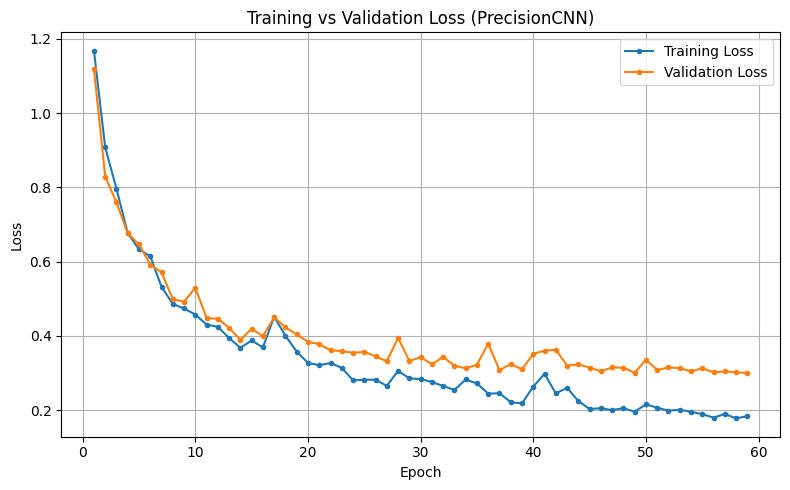

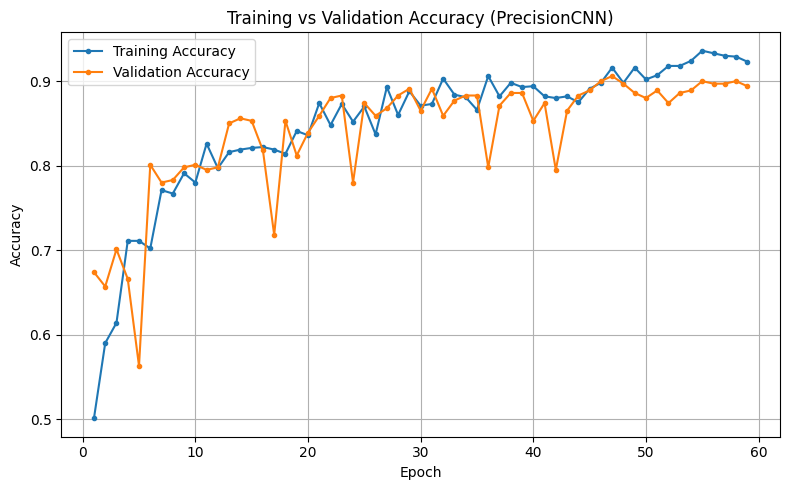

Saved: precisioncnn_loss_curve.png and precisioncnn_accuracy_curve.png


In [1]:
import matplotlib.pyplot as plt

# -----------------------
# 1. Metrics from the log (Epochs 1-59)
# -----------------------
train_loss = [
    1.1678, 0.9072, 0.7962, 0.6765, 0.6328, 0.6140, 0.5319, 0.4859, 0.4737, 0.4574,
    0.4301, 0.4246, 0.3940, 0.3677, 0.3876, 0.3688, 0.4517, 0.4002, 0.3575, 0.3271,
    0.3210, 0.3268, 0.3140, 0.2802, 0.2819, 0.2817, 0.2654, 0.3058, 0.2855, 0.2837,
    0.2757, 0.2652, 0.2539, 0.2827, 0.2718, 0.2444, 0.2456, 0.2213, 0.2183, 0.2636,
    0.2977, 0.2449, 0.2603, 0.2243, 0.2031, 0.2051, 0.2000, 0.2052, 0.1958, 0.2154,
    0.2065, 0.1986, 0.2011, 0.1954, 0.1891, 0.1799, 0.1897, 0.1779, 0.1837
]

val_loss = [
    1.1182, 0.8285, 0.7595, 0.6758, 0.6461, 0.5919, 0.5710, 0.4985, 0.4921, 0.5293,
    0.4478, 0.4460, 0.4218, 0.3892, 0.4193, 0.3989, 0.4503, 0.4228, 0.4039, 0.3840,
    0.3775, 0.3615, 0.3588, 0.3545, 0.3567, 0.3447, 0.3318, 0.3950, 0.3319, 0.3426,
    0.3233, 0.3433, 0.3199, 0.3126, 0.3225, 0.3788, 0.3075, 0.3241, 0.3098, 0.3518,
    0.3599, 0.3626, 0.3201, 0.3231, 0.3145, 0.3043, 0.3151, 0.3142, 0.3005, 0.3360,
    0.3078, 0.3151, 0.3132, 0.3042, 0.3129, 0.3018, 0.3044, 0.3014, 0.3006
]

train_acc = [
    0.501, 0.590, 0.614, 0.711, 0.711, 0.702, 0.771, 0.767, 0.791, 0.780,
    0.826, 0.797, 0.816, 0.819, 0.821, 0.822, 0.819, 0.814, 0.841, 0.836,
    0.874, 0.848, 0.873, 0.852, 0.870, 0.837, 0.893, 0.860, 0.888, 0.871,
    0.873, 0.903, 0.884, 0.881, 0.866, 0.906, 0.882, 0.898, 0.893, 0.894,
    0.882, 0.880, 0.882, 0.875, 0.891, 0.898, 0.916, 0.898, 0.916, 0.902,
    0.907, 0.918, 0.918, 0.924, 0.936, 0.933, 0.930, 0.929, 0.923
]

val_acc = [
    0.674, 0.657, 0.701, 0.666, 0.563, 0.801, 0.780, 0.783, 0.798, 0.801,
    0.795, 0.798, 0.850, 0.856, 0.853, 0.818, 0.718, 0.853, 0.812, 0.839,
    0.859, 0.880, 0.883, 0.780, 0.874, 0.859, 0.868, 0.883, 0.891, 0.865,
    0.891, 0.859, 0.877, 0.883, 0.883, 0.798, 0.871, 0.886, 0.886, 0.853,
    0.874, 0.795, 0.865, 0.883, 0.889, 0.900, 0.906, 0.897, 0.886, 0.880,
    0.889, 0.874, 0.886, 0.889, 0.900, 0.897, 0.897, 0.900, 0.894
]

epochs = list(range(1, len(train_loss) + 1))

# -----------------------
# 2. Loss curve
# -----------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', markersize=3, label='Training Loss')
plt.plot(epochs, val_loss, marker='o', markersize=3, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (PrecisionCNN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("precisioncnn_loss_curve.png", dpi=300)
plt.show()

# -----------------------
# 3. Accuracy curve
# -----------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, marker='o', markersize=3, label='Training Accuracy')
plt.plot(epochs, val_acc, marker='o', markersize=3, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (PrecisionCNN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("precisioncnn_accuracy_curve.png", dpi=300)
plt.show()

print("Saved: precisioncnn_loss_curve.png and precisioncnn_accuracy_curve.png")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 1. Confusion matrix (Updated)
# ============================
# From the provided log: [[ 56, 12, 2], [ 15, 212, 5], [ 1, 4, 34]]
cm = np.array([
    [56, 12,  2],
    [15, 212,  5],
    [ 1,  4, 34]
])

class_names = ["Entry-wise (0)", "Row-wise (1)", "Adaptive (2)"]

# ============================
# 2. Metrics (Updated)
# ============================
per_class_metrics = {
    "Entry-wise (0)": {"precision": 0.778, "recall": 0.800, "f1": 0.789, "support": 70},
    "Row-wise (1)":   {"precision": 0.930, "recall": 0.914, "f1": 0.922, "support": 232},
    "Adaptive (2)":   {"precision": 0.829, "recall": 0.872, "f1": 0.850, "support": 39},
}

overall_accuracy = 0.886
macro_avg = {"precision": 0.846, "recall": 0.862, "f1": 0.853}
weighted_avg = {"precision": 0.887, "recall": 0.886, "f1": 0.886}

# ==========================================
# A. Confusion Matrix Heatmap PNG
# ==========================================
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues) # Added cmap for better visual
plt.title("Confusion Matrix (Test Set)")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

# Write values inside the cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("precisioncnn_confusion_matrix.png", dpi=300)
plt.close()
print("Saved precisioncnn_confusion_matrix.png")

# ==========================================
# B. Per-class Precision / Recall / F1 PNG
# ==========================================
classes = list(per_class_metrics.keys())
precisions = [per_class_metrics[c]["precision"] for c in classes]
recalls    = [per_class_metrics[c]["recall"]    for c in classes]
f1s        = [per_class_metrics[c]["f1"]        for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(9, 6))
plt.bar(x - width, precisions, width, label="Precision", color='#1f77b4')
plt.bar(x,         recalls,   width, label="Recall",    color='#ff7f0e')
plt.bar(x + width, f1s,       width, label="F1-score",  color='#2ca02c')

plt.xticks(x, classes, rotation=20, ha="right")
plt.ylim(0.0, 1.05)
plt.ylabel("Score")
plt.title("Per-class Precision, Recall, and F1-score (Test Set)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("precisioncnn_prf1_per_class.png", dpi=300)
plt.close()
print("Saved precisioncnn_prf1_per_class.png")

# ==========================================
# C. Overall metrics (Accuracy + Macro/Weighted F1) PNG
# ==========================================
labels = ["Accuracy", "Macro F1", "Weighted F1"]
values = [
    overall_accuracy,
    macro_avg["f1"],
    weighted_avg["f1"]
]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0.0, 1.05)
plt.ylabel("Score")
plt.title("Overall Test Metrics (PrecisionCNN)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels on top of bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01,
             f"{val:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.savefig("precisioncnn_overall_metrics.png", dpi=300)
plt.close()
print("Saved precisioncnn_overall_metrics.png")

Saved precisioncnn_confusion_matrix.png
Saved precisioncnn_prf1_per_class.png
Saved precisioncnn_overall_metrics.png
